In [2]:
%%capture
#!pip install -r requirements.txt

In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import copy
import time
from concorde.tsp import TSPSolver

# Problem definition

    Rudolph the red-nosed reindeer 
    Had some very tired hooves 
    But he had a job to finish 
    Could he do it with the shortest moves?

    All of the other reindeer 
    Used to laugh and mock his code 
    They always said poor Rudolph 
    Couldn't handle the workload

    Then one foggy Christmas Eve 
    Santa came to say 
    I see you've taken number theory 
    Please make this night a bit less dreary?

    Then how the reindeer loved him 
    and each enrolled in an AI degree 
    Rudolph the red-nosed reindeer 
    We get to go to bed early!

- Paths must start and end at the North Pole (`CityId = 0`)
- You must visit every city exactly once
- The distance between two paths is the 2D Euclidean distance, except...
- Every 10th step (`stepNumber % 10 == 0`) is 10% more lengthy unless coming from a prime `CityId`.

# About the competition

- Ends: January 10, 2019 11:59 PM UTC
- Prize: $25,000
- URL: https://www.kaggle.com/c/traveling-santa-2018-prime-paths

# The dataset

In [10]:
#!kaggle competitions download -c traveling-santa-2018-prime-paths
df = pd.read_csv('cities.csv.zip', index_col='CityId')
print(df)

                  X            Y
CityId                          
0        316.836739  2202.340707
1       4377.405972   336.602082
2       3454.158198  2820.053011
3       4688.099298  2935.898056
4       1010.696952  3236.750989
5       2474.230877  1435.514651
6       1029.277795  2721.800952
7       3408.887685   199.585793
8       1304.006125  2657.427246
9       4211.525725  2294.595208
10       297.575458  1952.548486
11      2052.116500   578.293526
12      2645.077176  2717.838772
13       965.611152  1067.734281
14       454.988723  1217.670993
15      3369.344927  1504.603740
16      4944.059453  2326.338189
17      4313.207563  2800.438423
18      2352.743647  2489.939529
19      3033.179607   515.217613
20      3421.865966  1597.526985
21      4326.667571  1607.378707
22      1383.884494  3167.747210
23      3633.815728  2889.995167
24      3694.082279   734.949757
25      4646.266998  2884.589219
26      4587.094869   713.341441
27      4310.142275  3267.646528
28      27

In [11]:
print(df.describe())

                   X              Y
count  197769.000000  197769.000000
mean     2741.169734    1859.277703
std      1474.870239     985.144313
min         1.871925       0.000000
25%      1439.292001    1054.234324
50%      2772.522934    1946.624393
75%      4246.994405    2736.536831
max      5099.502142    3397.809824


# Travelling salesman problem

![nfactorial](https://cdn-images-1.medium.com/max/1600/1*tXDAZzUr_Iijsc1kSTtzxA.jpeg)
Source: https://medium.com/basecs/speeding-up-the-traveling-salesman-using-dynamic-programming-b76d7552e8dd

# Generate range of prime numbers

In [14]:
def prime_range(lower, upper):
    primes = set([2])
    for num in range(lower,upper + 1):
        if num > 1:
            for p in primes:
                if (num % p) == 0:
                    break
            else:
                primes.add(num)
    return primes

n_cities = len(df)
primes = prime_range(0, n_cities + 1)
print(len(primes))

17802


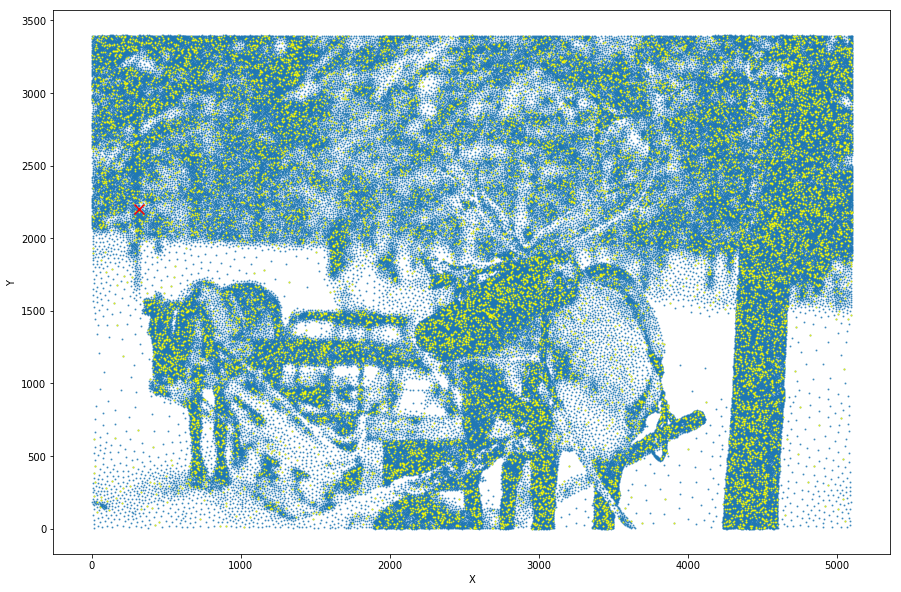

In [15]:
ax = df.plot(kind='scatter', x='X', y='Y', figsize=(15,10), s=1, alpha=0.7)
df.loc[primes].plot(kind='scatter', x='X', y='Y', s=1, c='yellow', ax=ax, alpha=0.7)
df.loc[[0]].plot(kind='scatter', x='X', y='Y', c='red', ax=ax, marker='x', s=100)

# Helper Functions

In [16]:
def distance(j, k, dist_cache):
    d = dist_cache.get((j, k), (((df.iloc[j].values - df.iloc[k].values)**2).sum())**0.5)
    dist_cache[(j, k)] = dist_cache[(k, j)] = d
    return d

def evaluate_route(route, dist_cache):
    dist_sum = 0
    for i, (j, k) in enumerate(zip(route[:-1], route[1:])):
        dist = distance(j, k, dist_cache=dist_cache)
        # Add 10% to the distance if not coming from a prime city
        if i%10 == 0:
            if j not in primes:
                dist *= 1.1
        dist_sum += dist
        j = k
    return dist_sum

def plot_eval(evalution, N=5, ax=None):
    if ax == None:
        fig, ax = plt.subplots(figsize=(15,10))
    moving_average = np.convolve(evaluation, np.ones((N,))/N, mode='valid')
    ax.plot(moving_average)

def plot_path(path_list, ax=None):
    df_subset = df.iloc[path_list]
    if ax == None:
        fig, ax = plt.subplots(figsize=(15,10))
    df_subset.plot(x='X', y='Y', alpha=0.7, legend=False, ax=ax, linewidth=1)
    df_subset.plot(kind='scatter', x='X', y='Y', ax=ax, color=range(len(path_list)), s=1)
    df_subset.loc[[0]].plot(kind='scatter', x='X', y='Y', c='red', ax=ax, marker='x', s=100)

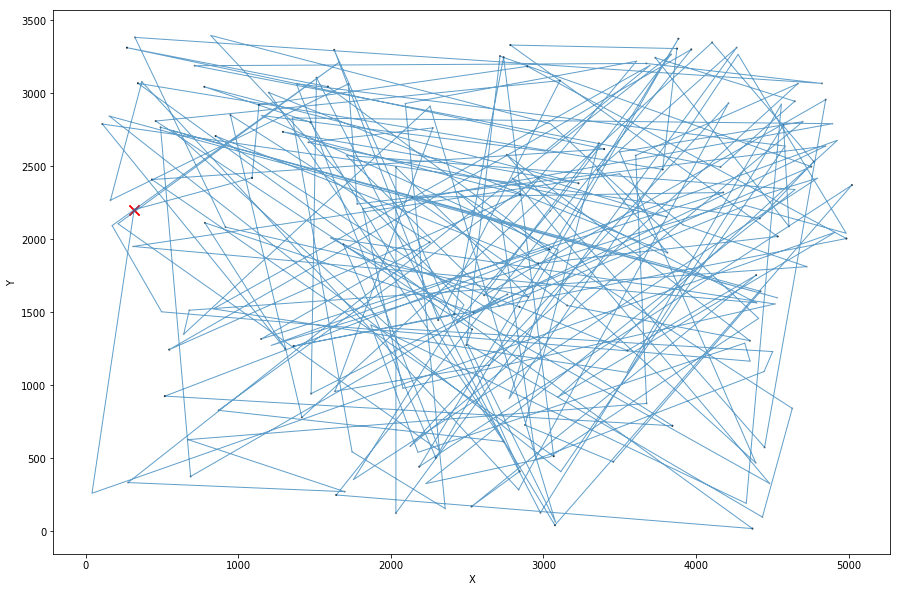

In [20]:
n_sample = int(0.001 * n_cities)
dist_cache = {}
evaluation = []
perm = np.random.permutation(n_cities)[:n_sample]
df_subset = df.loc[1:].iloc[perm]
df_subset.loc[0] = df.loc[0]
df_subset.sort_index(inplace=True)
best_route = route = df_subset.index.tolist() + [0]
best_routes = [best_route]
best_route_len = route_len = evaluate_route(route, dist_cache)
plot_path(route)

Number of nodes: 199 | Number of swaps: 1836 | Best route length: 208247.17299201962


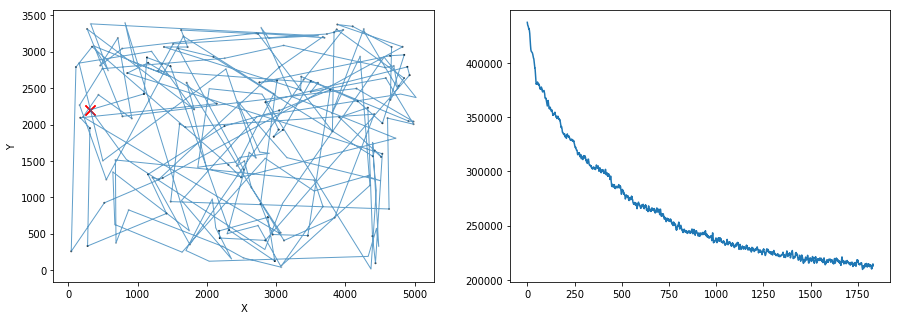

In [24]:
cur_temp = 1.
end_temp = 0.01
cool_rate = 0.99
while cur_temp > end_temp:
    new_route = copy.deepcopy(route)
    for i in range(1):
        j, k = random.sample(range(1, n_sample - 1), 2)
        new_route[k], new_route[j] = new_route[j], new_route[k]
    new_route_len = evaluate_route(new_route, dist_cache)
    evaluation.append(new_route_len)
    if new_route_len < best_route_len:
        p = 1.
        best_route, best_route_len = new_route, new_route_len
        best_routes.append(best_route)
    else:
        p = np.exp((route_len - new_route_len) / cur_temp)
    if random.random() < p:
        route, route_len = new_route, new_route_len
    cur_temp *= cool_rate

print('Number of nodes:', len(route), '| Number of swaps:', len(evaluation), '| Best route length:', best_route_len)

fig, axes = plt.subplots(1, 2, figsize=(15,5))
plot_path(best_route, ax=axes[0])
plot_eval(evaluation, ax=axes[1])

# Half baked nearest neighbour approach:

- Use nearest neighbour to generate initial path rather than random initialisatopm
- Use simulated annealing to optimise 

In [10]:
from scipy.spatial import cKDTree
class VisitTracker(object):
    def __init__(self, unvisited):
        self.unvisited = set(unvisited)
        self.visited = set()

    def visit(self, city):
        self.unvisited.remove(city)
        self.visited.add(city)

t_subset = cKDTree(df_subset)
d, n = t_subset.query(t_subset.data, k=150)
print(n)

[[  0 161 157 ...  22 121  81]
 [  1 143  83 ...  76 164  86]
 [  2  96 160 ... 153  26  12]
 ...
 [178 124  42 ...  38  80   3]
 [179 110  40 ... 112  65  79]
 [180 136  69 ... 115 138 127]]


In [25]:
cur_index = 0
vt = VisitTracker(range(len(df_subset)))
vt.visit(cur_index)
while len(vt.unvisited) > 0:
    for nxt_index in n[cur_index]:
        if nxt_index in vt.unvisited:
            vt.visit(nxt_index)
        else:
            cur_index = nxt_index
            break

NameError: name 'VisitTracker' is not defined

In [ ]:
df_subset.loc[unvisited]

# Concorde solver cheat

In [8]:
if False:
    solver = TSPSolver.from_data(
        df.X,
        df.Y,
        norm="EUC_2D"
    )

    t = time.time()
    tour_data = solver.solve(time_bound=60.0, verbose=True, random_seed=42) # solve() doesn't seem to respect time_bound for certain values?
    print(time.time() - t)
    print(tour_data.found_tour)
    plot_path(tour_data.tour)

Competition score: **1533361.98**

![competition](https://i.imgur.com/cJC2c7B.png)

# Other things I'd like to try:

- parallel route search
- evolutionary algorithm?
- open to other suggestions

# Team up?

- Team: https://www.kaggle.com/c/traveling-santa-2018-prime-paths/team
- GitHub: https://github.com/brtknr/TravellingSanta

# Thanks for your attention!